In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [30]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [31]:
# download LightGBM package
!pip install lightgbm

In [32]:
# LGBM dependencies
import lightgbm as lgbm
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [33]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [34]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'candidate_count']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


In [35]:
#log transforming target
train['log_price'] = np.log1p(train['price_usd_real'])

#groups each instrument type of the train set by its mean/median price
type_mean = train.groupby('type')['log_price'].mean()  
type_median = train.groupby('type')['log_price'].median()

type_mean.head()

type
Bass          9.835546
Bass Bow      7.830970
Bass Viol    11.087919
Cello        10.124304
Cello Bow     8.540933
Name: log_price, dtype: float64

We will temporarily create two new columns in the validation set to predict the price of each instrument sale using our means/medians above.

In [36]:
#check for missing values
print(X_train['type'].isna().any())
print(X_valid['type'].isna().any())

#creating new columns
valid['type_mean']= valid['type'].map(type_mean)
valid['type_median'] = valid['type'].map(type_median)
valid.head()

False
False


,sale_date,maker_id,maker_name,type,city_maker,auction_house,lot,bold_currency,Year,Month,...,MCI,real_price_gold,country_iso1,admin1_name,admin2_name,role,maker_last_name,birth_cent,type_mean,type_median
0,2000-02-14,2827,"Collin-Mézin, Charles Jean-Baptiste III",Violin,Paris,Phillip's,25,gbp,2000,2,...,-6.037718,588.0587,FR,Île-de-France,Paris,Violin maker,Collin-Mézin,20.0,9.159512,8.991187
1,1995-11-14,356,"Thibouville-Lamy, Jérôme Firm",Violin,Mirecourt,Bonhams,309,gbp,1995,11,...,4.018622,815.9887,FR,Grand Est,Vosges,Bow maker / Violin maker,Thibouville-Lamy,19.0,9.159512,8.991187
2,2008-10-07,185,"Gadda, Mario",Cello,Mantua,Sotheby's,136,gbp,2008,10,...,-4.978523,1331.5068,IT,Lombardy,Provincia di Mantova,Violin maker,Gadda,20.0,10.124304,10.062779
3,1993-05-23,1327,"Huber, Johann Georg",Viola,Vienna,Skinner,164,usd,1993,5,...,1.206404,851.0234,AT,Vienna,Wien Stadt,Violin maker,Huber,18.0,9.097133,9.065886
4,2010-10-10,524,"Pedrazzini, Giuseppe",Violin,Cremona,Skinner,-,usd,2010,10,...,3.251219,2002.1250,IT,Lombardy,Provincia di Cremona,Violin maker,Pedrazzini,19.0,9.159512,8.991187


In [37]:
#evaluating base model
print("Base model: Predicting prices by mean and median of train set \n")
print("Mean")
evaluate_model(Y_valid, valid['type_mean'])

print("\n Median")
evaluate_model(Y_valid, valid['type_median'])

Base model: Predicting prices by mean and median of train set 

Mean
------ LOG METRICS ------
RMSE_log: 1.285456313665743
MAE_log: 0.988432919402884
R2_log: 0.10001861657415356
MAPE_log: 0.11279419733674426

------ PRICE METRICS ($) ------
RMSE: 125935.18437162781
MAE: 22152.072084267635
R2: -0.014001477146394548
MAPE: 1.5594670219204665

 Median
------ LOG METRICS ------
RMSE_log: 1.2931641897639936
MAE_log: 0.9841738236638584
R2_log: 0.0891932891990842
MAPE_log: 0.11087921033874927

------ PRICE METRICS ($) ------
RMSE: 126116.55690583902
MAE: 22118.01709392209
R2: -0.016924321211996718
MAPE: 1.3814586533054676


In [21]:
#dropping columns we created for base model
valid = valid.drop(columns = ['type_mean', 'type_median'])
train = train.drop(columns = ['log_price'])

In [ ]:
#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")

sale_date has 941 unique values
maker_name has 3060 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
lot has 1244 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
role has 34 unique values
maker_last_name has 2164 unique values


C:\Users\Sean\AppData\Local\Temp\ipykernel_10636\1795891500.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [54]:
LowCardCols = ["type", "bold_currency"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

In [55]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [56]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [57]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [58]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)




We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [59]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train))



c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [60]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

print("Lassocv model evaluation: \n")
evaluate_model(Y_valid, lasso_pred)


#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("\nOptimal alpha:", f"{optimal_alpha:.5f}")


Lassocv model evaluation: 

------ LOG METRICS ------
RMSE_log: 0.6584080815567188
MAE_log: 0.5017359614433081
R2_log: 0.7638928231164228
MAPE_log: 0.058211365794207125

------ PRICE METRICS ($) ------
RMSE: 99207.44820468583
MAE: 13996.372828001075
R2: 0.37073586339306774
MAPE: 0.6492848284193581

Optimal alpha: 0.00125


In [61]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

#errors in log prices
rmse = mean_squared_error(np.log1p(Y_valid), lasso_pred)
r2 = r2_score(np.log1p(Y_valid), lasso_pred)
mae = mean_absolute_error(np.log1p(Y_valid), lasso_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)

#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("Optimal alpha:", f"{optimal_alpha:.5f}")


RMSE: 0.4335012018591988
R^2: 0.7638928231164228
mae: 0.5017359614433081
Optimal alpha: 0.00125


In [62]:
#prediction in USD
lasso_pred_dollars = np.expm1(lasso_pred)

#mape and mae instead of r^2 and rmse
mape = mean_absolute_percentage_error(Y_valid, lasso_pred_dollars)
mae = mean_absolute_error(Y_valid, lasso_pred_dollars)
print("mape:", mape)
print("mae:", mae)

mape: 0.6492848284193581
mae: 13996.372828001075


In [63]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [64]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__cpi_usd
num__gbp_usd_x
num__SP500_ma200
num__10y_yield_90d_change
num__Year
num__SP500_vol_30d
num__SP500_trend_ratio


In [65]:
#prints each feature and its corresponding coefficient
feature_and_coeff = []
for i in range(len(feature_names)):
    feature_and_coeff.append( ( feature_names[i], coefficients[i] ))
for x in feature_and_coeff:
    print(x)

('lognum__real_price_gold', np.float64(-0.018267365296591898))
('lognum__SP500_real', np.float64(0.016919318300886086))
('lowcard__type_Bass', np.float64(0.0))
('lowcard__type_Bass Bow', np.float64(-0.0))
('lowcard__type_Bass Viol', np.float64(0.0))
('lowcard__type_Cello', np.float64(0.8033513715446863))
('lowcard__type_Cello Bow', np.float64(-0.04860246539923809))
('lowcard__type_Miscellaneous', np.float64(0.0))
('lowcard__type_Small Violin', np.float64(-0.28551621809212446))
('lowcard__type_Tenor Viol', np.float64(0.0))
('lowcard__type_Treble Viol', np.float64(0.0))
('lowcard__type_Viola', np.float64(0.0408469044799369))
('lowcard__type_Viola Bow', np.float64(-0.0))
("lowcard__type_Viola d'Amore", np.float64(0.0))
('lowcard__type_Violin', np.float64(0.010171462868009578))
('lowcard__type_Violin Bow', np.float64(-0.14492642295378313))
('lowcard__bold_currency_eur', np.float64(-0.01223631044794185))
('lowcard__bold_currency_gbp', np.float64(0.02336752495502365))
('lowcard__bold_currenc

In [66]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.2512376  1.16690837 1.08826265 1.01491739 0.94651536 0.88272339
 0.82323079 0.76774779 0.71600416 0.66774787 0.6227439  0.58077305
 0.54163089 0.50512678 0.47108292 0.43933351 0.4097239  0.38210988
 0.35635696 0.33233969 0.30994111 0.28905211 0.26957097 0.25140279
 0.23445908 0.21865732 0.20392055 0.19017699 0.1773597  0.16540625
 0.15425842 0.14386192 0.13416611 0.12512376 0.11669084 0.10882627
 0.10149174 0.09465154 0.08827234 0.08232308 0.07677478 0.07160042
 0.06677479 0.06227439 0.0580773  0.05416309 0.05051268 0.04710829
 0.04393335 0.04097239 0.03821099 0.0356357  0.03323397 0.03099411
 0.02890521 0.0269571  0.02514028 0.02344591 0.02186573 0.02039206
 0.0190177  0.01773597 0.01654062 0.01542584 0.01438619 0.01341661
 0.01251238 0.01166908 0.01088263 0.01014917 0.00946515 0.00882723
 0.00823231 0.00767748 0.00716004 0.00667748 0.00622744 0.00580773
 0.00541631 0.00505127 0.00471083 0.00439334 0.00409724 0.0038211
 0.00356357 0.0033234  0.00309941 0.00289052 0.00269571 0.00251

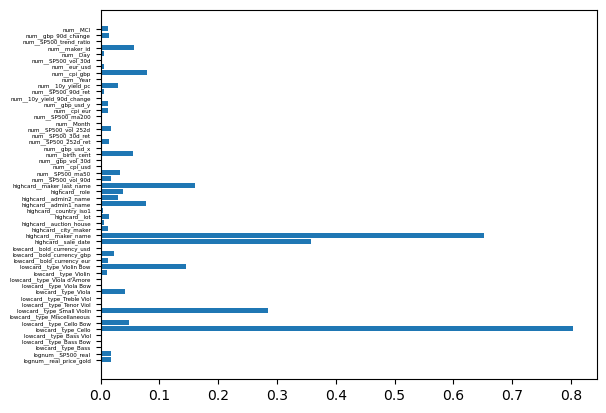

<Figure size 1200x600 with 0 Axes>

In [67]:


abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=4)
plt.figure(figsize=(12,6))
plt.show()

In [68]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

forest_pred = rf.predict(X_valid)

evaluate_model(Y_valid, forest_pred)

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------ LOG METRICS ------
RMSE_log: 0.617479315228917
MAE_log: 0.4679262242541678
R2_log: 0.7923348068951002
MAPE_log: 0.05437411405676059

------ PRICE METRICS ($) ------
RMSE: 72603.03524825706
MAE: 11764.998944927574
R2: 0.6629813167342823
MAPE: 0.592622871773235


# New Model: LightGBM

Define the Model with default parameters.

In [35]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

In [36]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [37]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64],
    "model__learning_rate": [0.008, 0.009, 0.01, 0.011, 0.012],
    "model__n_estimators": [2300, 2500, 2700, 2900],
    "model__max_depth": [-1]
}


search = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [38]:
search.fit(X_train, np.log1p(Y_train.values.ravel()))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.008, 0.009, ...], 'model__max_depth': [-1], 'model__n_estimators': [2300, 2500, ...], 'model__num_leaves': [62, 63, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valida

In [39]:
best_model = search.best_estimator_
print(search.best_params_)

{'model__num_leaves': 62, 'model__n_estimators': 2700, 'model__max_depth': -1, 'model__learning_rate': 0.009}


### Prediction

In [40]:
y_pred_log_lgbm = best_model.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Comparison of LGBM with Lasso

In [41]:
evaluate_model(Y_valid, lasso_pred)

------ LOG METRICS ------
RMSE_log: 0.6585687341245148
MAE_log: 0.5021004568064128
R2_log: 0.7637775880427896
MAPE_log: 0.05823846674479882

------ PRICE METRICS ($) ------
RMSE: 100039.36726255504
MAE: 14081.743005546443
R2: 0.3601380349418212
MAPE: 0.6491837811679347


In [42]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5935842657239443
MAE_log: 0.4503073825869507
R2_log: 0.8080961695323133
MAPE_log: 0.05235533568101883

------ PRICE METRICS ($) ------
RMSE: 80814.61464208334
MAE: 11713.013125243753
R2: 0.5824348591475218
MAPE: 0.5683714294288875
